Estimated weights: [0.36474877 0.18260115 0.45265008]
Estimated means: [-0.21790382  5.47759425  3.38735896]
Estimated stds: [0.81600733 0.92522473 2.30964505]


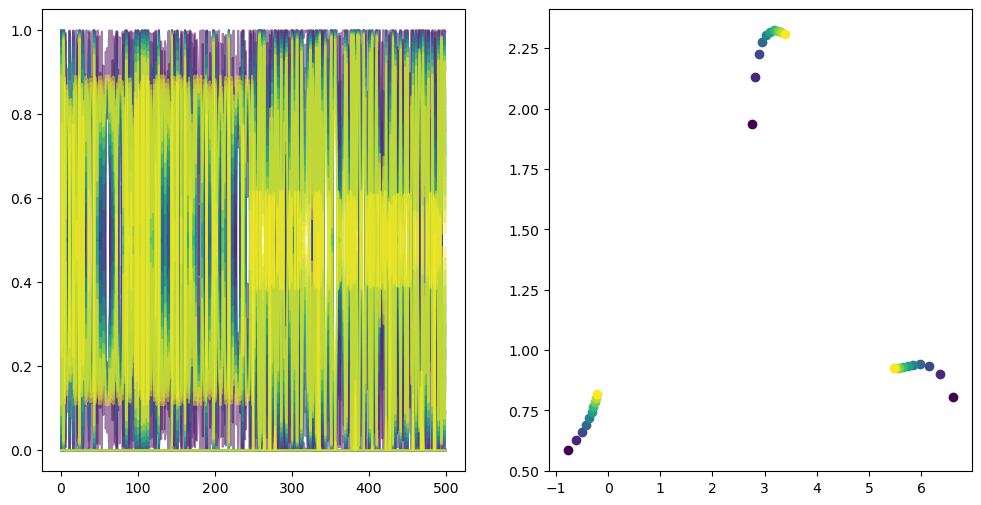

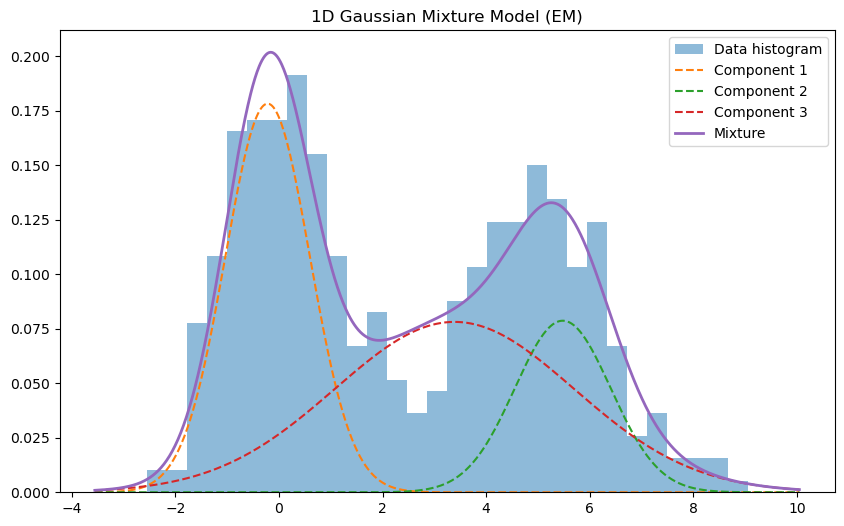

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate data
np.random.seed(0)
n = 500
X = np.concatenate([
    np.random.normal(loc=0, scale=1, size=n//2),
    np.random.normal(loc=5, scale=1.5, size=n//2)
])

# Step 2: Initialize parameters
k = 3  # number of components
weights = np.ones(k) / k  # equal weights
means = np.array([np.min(X), np.max(X), np.mean(X)])  # initial means
stds = np.ones(k)  # initial stds

def gaussian(x, mu, sigma):
    return (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# EM algorithm
T = 10  # number of iterations
colors = plt.cm.viridis(np.linspace(0, 1, T))

for iteration in range(T):
    # E-step: compute responsibilities
    responsibilities = np.zeros((n, k))
    for i in range(k):
        responsibilities[:, i] = weights[i] * gaussian(X, means[i], stds[i])
    responsibilities /= responsibilities.sum(axis=1, keepdims=True)

    ax[0].plot(responsibilities, color=colors[iteration], alpha=0.5)

    # M-step: update parameters
    Nk = responsibilities.sum(axis=0)
    weights = Nk / n
    means = (responsibilities * X[:, np.newaxis]).sum(axis=0) / Nk
    stds = np.sqrt(((responsibilities * (X[:, np.newaxis] - means) ** 2).sum(axis=0)) / Nk)
    ax[1].plot(means, stds, 'o', label=f'Iteration {iteration+1}', color=colors[iteration])

plt.figure(figsize=(10, 6))
# Final estimated parameters
print("Estimated weights:", weights)
print("Estimated means:", means)
print("Estimated stds:", stds)

# Plotting
x_plot = np.linspace(np.min(X) - 1, np.max(X) + 1, 1000)
pdf = np.zeros_like(x_plot)
for i in range(k):
    pdf += weights[i] * gaussian(x_plot, means[i], stds[i])

plt.hist(X, bins=30, density=True, alpha=0.5, label="Data histogram")
for i in range(k):
    plt.plot(x_plot, weights[i] * gaussian(x_plot, means[i], stds[i]), '--', label=f'Component {i+1}')
plt.plot(x_plot, pdf, label="Mixture", linewidth=2)
plt.legend()
plt.title("1D Gaussian Mixture Model (EM)")
plt.show()
